In [1]:
import model
import epidemic_simulation
import survey_design
import random
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import arviz
import cmdstanpy
from cmdstanpy import CmdStanModel

In [167]:
random.seed(12345)
np.random.seed(12345)

In [168]:
f_infectious, f_recovered, delay_inf, delay_recov = epidemic_simulation.delays()
transmission_rate = epidemic_simulation.transmission_rate
m = model.AgentModel(1000000, 50)

m.transmission_rate = transmission_rate
m.f_infectious = f_infectious
m.f_recovered = f_recovered
df = m.simulate(365)

In [197]:
case_ascertainment = 0.1
cases = case_ascertainment * np.asarray(df['transmissions'])[10:300]

In [198]:
stan_data = {
    'T': len(cases),
    'cases': cases,
}
cmdstanpy.write_stan_json('stan_data_cases.json', stan_data)

inference_model = CmdStanModel(stan_file='model_cases_only.stan', cpp_options={'STAN_THREADS':'true'})

num_mcmc = 1000

fit = inference_model.sample(data='stan_data_cases.json',
    iter_warmup=num_mcmc // 2,
    iter_sampling=num_mcmc // 2,
    seed=123,
    chains=2,
    adapt_delta=0.99,
    max_treedepth=8,
    output_dir='output_cases_only',
)

results = arviz.from_cmdstanpy(fit)
rhat = arviz.rhat(results)


17:18:10 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

17:18:10 - cmdstanpy - INFO - CmdStan done processing.
17:18:10 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model_cases_only.stan', line 21, column 4 to column 58)
Consider re-running with show_console=True if the above output is unclear!


(array([  7.,  33., 111., 204., 273., 210., 114.,  40.,   7.,   1.]),
 array([0.0619229 , 0.06389827, 0.06587364, 0.06784901, 0.06982438,
        0.07179975, 0.07377512, 0.07575049, 0.07772586, 0.07970123,
        0.0816766 ]),
 <BarContainer object of 10 artists>)

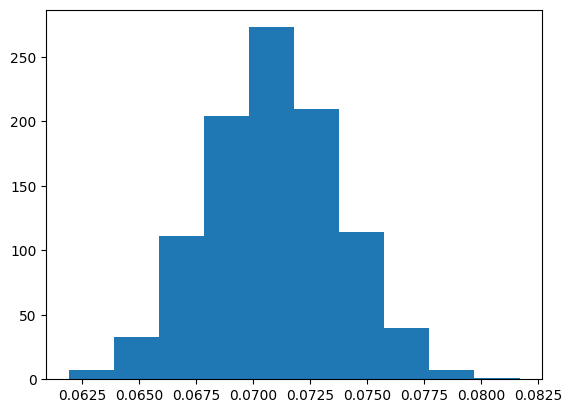

In [199]:
plt.hist(fit.rw)

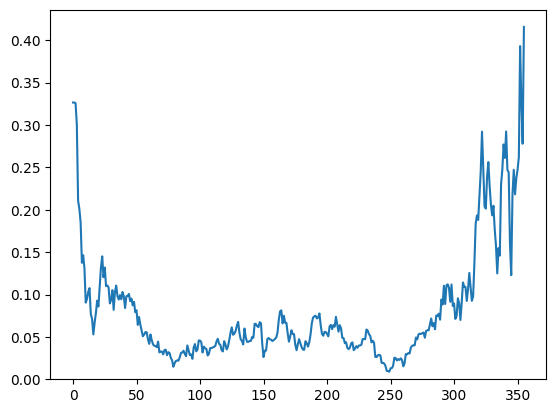

In [220]:
x = np.abs(np.diff(np.log(df['transmissions'][1:] + 1)))
x_sliding = [np.mean(x[i:i + 7]) for i in range(len(x) - 7)]

plt.plot(x_sliding)

plt.ylim(0, None)

plt.show()

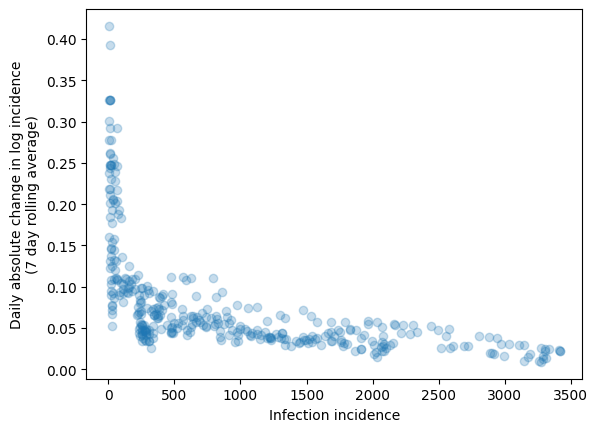

In [224]:
plt.scatter(df['transmissions'][1:-8], x_sliding, alpha=0.25)
plt.xlabel('Infection incidence')
plt.ylabel('Daily absolute change in log incidence\n(7 day rolling average)')
plt.show()

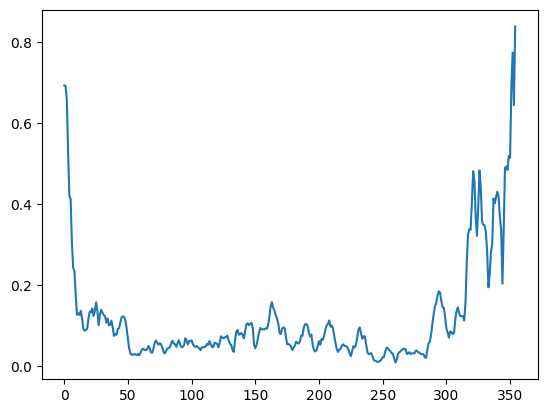

In [231]:
log_i = np.log(df['transmissions'][1:])
log_i = np.asarray(log_i)

diff2 = np.abs(log_i[2:] - 2 * log_i[1:-1] + log_i[:-2])

diff2_sliding = [np.mean(diff2[i:i + 7]) for i in range(len(diff2) - 7)]

plt.plot(diff2_sliding)


plt.show()

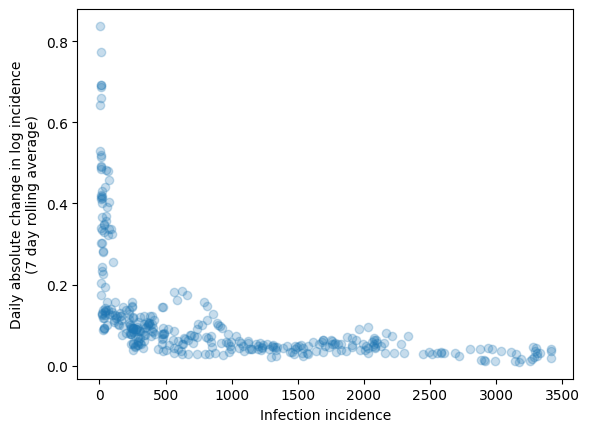

In [232]:
plt.scatter(df['transmissions'][1:-9], diff2_sliding, alpha=0.25)
plt.xlabel('Infection incidence')
plt.ylabel('Daily absolute change in log incidence\n(7 day rolling average)')
plt.show()

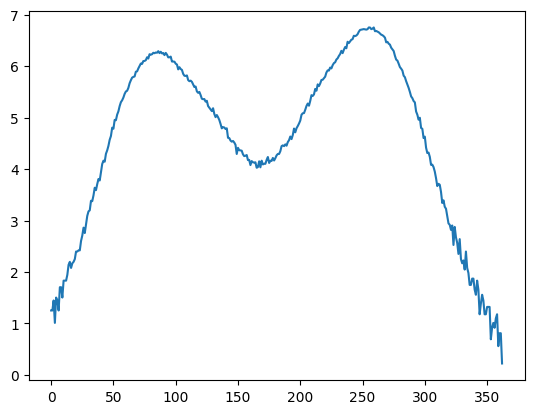

In [189]:
plt.plot(np.log(cases + 1))